<a href="https://colab.research.google.com/github/ansaganakhat/project-1/blob/main/01_kNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# k-жақын көршілер алгоритмі (k-Nearest Neighbors, kNN)


## Сабақтың мақсаты

Осы сабақтың соңында сіз:

- kNN алгоритмінің математикалық негізін түсінесіз
- Алгоритмді Python тілінде нөлден өзіңіз жазасыз
- scikit-learn кітапханасын пайдаланып нақты деректер жиынтығында үлгі үйретесіз
- Гиперпараметрлерді таңдаудың маңыздылығын бағалайсыз

## 1. Теориялық негіз

**Мақсат:** kNN алгоритмінің жұмыс принципін және математикалық негізін үйрену.

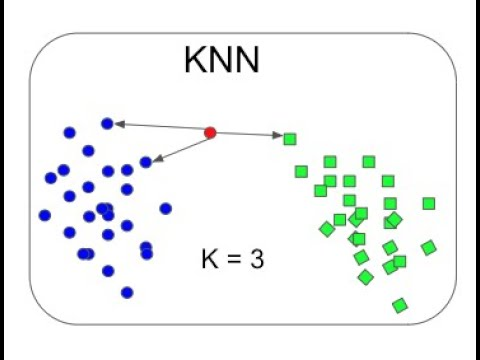

### 1.1 Интуитивтік түсінік

k-жақын көршілер алгоритмі — машиналық оқытудағы ең қарапайым, бірақ тиімді әдістердің бірі. Оның негізгі идеясы өте қарапайым: **ұқсас объектілер бір-біріне жақын орналасады**.

Мысалды қарастырайық. Жаңа қалаға қоныс аударған адам дәрігер іздейді делік. Ол өз іздеген дәрігерді табу үшін ең жақын көрші ауданда тұратын 5 адамнан кеңес сұрайды. Кеңес берушілердің көпшілігі ұсынған дәрігерді таңдайды. Осы қарапайым логика kNN алгоритмінің негізін құрайды.

Алгоритм екі есеп үшін қолданылады:

- **Классификация:** жаңа объектінің класын анықтау (мысалы, хатты "спам" немесе "спам емес" деп белгілеу)
- **Регрессия:** жаңа объектінің сандық мәнін болжау (мысалы, үй бағасын болжау)

### 1.2 Математикалық негіз

#### Арақашықтық өлшемдері

kNN алгоритмінің жүрегінде арақашықтықты есептеу жатыр. Екі нүктенің қаншалықты "жақын" екенін анықтау үшін бірнеше өлшем қолданылады.

**Евклид арақашықтығы (Euclidean Distance)**

Екі нүкте берілсін: $\mathbf{x} = (x_1, x_2, \ldots, x_n)$ және $\mathbf{y} = (y_1, y_2, \ldots, y_n)$.

$$d_E(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

Бұл ең жиі қолданылатын арақашықтық өлшемі. Геометриялық тұрғыдан алғанда — бұл екі нүкте арасындағы тікелей сызықтың ұзындығы.

**Манхэттен арақашықтығы (Manhattan Distance)**

$$d_M(\mathbf{x}, \mathbf{y}) = \sum_{i=1}^{n} |x_i - y_i|$$

Атауы Манхэттен қаласының тор тәрізді көшелерінен шыққан. Тек горизонталь және вертикаль қозғалысқа рұқсат берілгендей есептеледі.

**Минковский арақашықтығы (Minkowski Distance)**

$$d_p(\mathbf{x}, \mathbf{y}) = \left(\sum_{i=1}^{n} |x_i - y_i|^p\right)^{1/p}$$

Бұл — жалпыланған формула. $p=1$ болғанда Манхэттен, $p=2$ болғанда Евклид арақашықтығына айналады.

#### Алгоритмнің жұмыс қадамдары

1. Үйрету жиынтығын жадта сақтау (kNN — "жалқау" оқу алгоритмі, себебі үйрету кезеңінде ешқандай есептеу жүргізілмейді)
2. Жаңа объект келгенде, үйрету жиынтығының барлық объектілеріне дейінгі арақашықтықты есептеу
3. Ең жақын $k$ объектіні (көршіні) таңдау
4. **Классификация үшін:** $k$ көршінің ішіндегі ең жиі кездесетін класты қайтару
5. **Регрессия үшін:** $k$ көршінің мәндерінің орташасын қайтару

#### k параметрін таңдау

$k$ параметрі алгоритмнің негізгі гиперпараметрі болып табылады:

- **Кішкене $k$ (мысалы, $k=1$):** Үлгі өте икемді болады, шу мен аномалияларға сезімтал — асыра оқыту (overfitting) қаупі жоғары
- **Үлкен $k$ (мысалы, $k=N$):** Үлгі өте қатаң болады, барлығын ең жиі кездесетін класқа жатқызады — жетіспей оқыту (underfitting) қаупі жоғары
- **Оңтайлы $k$:** Крест-валидация (cross-validation) арқылы табылады

## 2. Машиналық оқыту кезеңдері

**Мақсат:** Кез келген ML жобасында қолданылатын стандартты кезеңдерді меңгеру.

Кез келген машиналық оқыту жобасы мынадай кезеңдерден тұрады:

1. **Деректерді жинау және жүктеу** — нақты деректер жиынтығын алу
2. **Зерттеу деректерін талдау (EDA)** — деректердің құрылымын, бөлінісін, корреляциясын зерттеу
3. **Деректерді алдын ала өңдеу** — жоқ мәндерді толтыру, масштабтау, кодтау
4. **Деректерді бөлу** — үйрету және тексеру жиынтықтарына бөлу
5. **Үлгіні үйрету** — алгоритмді деректерге сәйкестендіру
6. **Бағалау** — үлгінің сапасын өлшеу
7. **Гиперпараметрлерді реттеу** — үлгіні жақсарту
8. **Нәтижелерді талдау** — қорытынды шығару

## 3. Кітапханаларды импорттау

**Мақсат:** Жұмыс үшін қажетті барлық кітапханаларды дайындау.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from collections import Counter

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['font.size'] = 12
np.random.seed(42)

print('Барлық кітапханалар сәтті импортталды.')

Барлық кітапханалар сәтті импортталды.


## 4. Деректерді жүктеу және зерттеу

**Мақсат:** Iris деректер жиынтығымен танысу және оның негізгі сипаттамаларын зерттеу.

Біз **Iris** деректер жиынтығын қолданамыз. Бұл — машиналық оқытуда классикалық болып саналатын деректер жиынтығы. 1936 жылы ботаник Рональд Фишер жинақтаған бұл деректер 150 ирис гүлін сипаттайды.

Деректер жиынтығындағы белгілер (features):

- `sepal length` — тостағанша жапырақшасының ұзындығы (см)
- `sepal width` — тостағанша жапырақшасының ені (см)
- `petal length` — күлтенің ұзындығы (см)
- `petal width` — күлтенің ені (см)

Мақсатты айнымалы (target): гүл түрі — Setosa, Versicolor, Virginica

In [5]:
# Деректер жиынтығын жүктеу
iris = load_iris()
X = iris.data
y = iris.target

# Pandas DataFrame-ге айналдыру
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
df['species'] = df['target'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

print('Деректер жиынтығының өлшемі:', X.shape)
print('Класстар:', iris.target_names)
print('\nАлғашқы 5 жол:')
df.head()

Деректер жиынтығының өлшемі: (150, 4)
Класстар: ['setosa' 'versicolor' 'virginica']

Алғашқы 5 жол:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


In [6]:
# Сипаттамалық статистика
print('Сипаттамалық статистика:')
df.describe()

Сипаттамалық статистика:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


Класстардың үлестірімі:
species
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


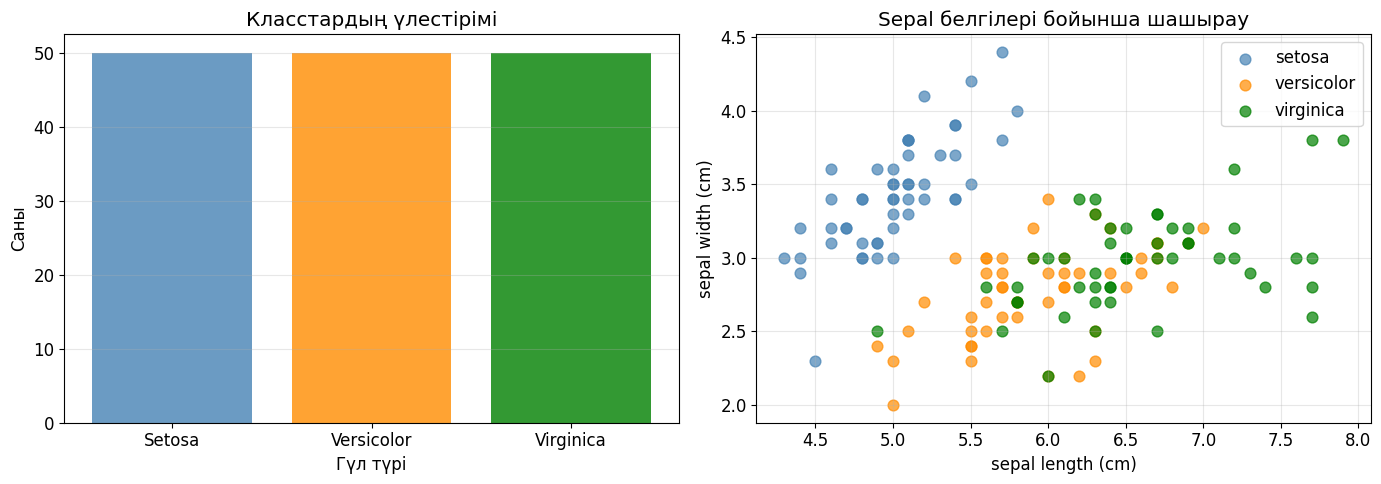

In [7]:
# Класстардың үлестірімі
print('Класстардың үлестірімі:')
print(df['species'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Класстардың санау диаграммасы
species_counts = df['species'].value_counts()
axes[0].bar(species_counts.index, species_counts.values, color=['steelblue', 'darkorange', 'green'], alpha=0.8)
axes[0].set_title('Класстардың үлестірімі')
axes[0].set_xlabel('Гүл түрі')
axes[0].set_ylabel('Саны')
axes[0].grid(axis='y', alpha=0.3)

# Белгілердің шашырау диаграммасы
colors = ['steelblue', 'darkorange', 'green']
for i, (species, color) in enumerate(zip(iris.target_names, colors)):
    mask = y == i
    axes[1].scatter(X[mask, 0], X[mask, 1], c=color, label=species, alpha=0.7, s=60)

axes[1].set_xlabel(iris.feature_names[0])
axes[1].set_ylabel(iris.feature_names[1])
axes[1].set_title('Sepal белгілері бойынша шашырау')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. kNN алгоритмін нөлден жазу

**Мақсат:** Алгоритмнің ішкі жұмыс принципін терең түсіну үшін оны Python тілінде нөлден іске асыру.

In [8]:
class KNNClassifierScratch:
    """
    k-жақын көршілер классификаторы — нөлден іске асыру.

    Параметрлер:
    -----------
    k : int
        Көршілер саны (гиперпараметр)
    metric : str
        Арақашықтық өлшемі: 'euclidean' немесе 'manhattan'
    """

    def __init__(self, k=3, metric='euclidean'):
        self.k = k
        self.metric = metric
        self.X_train = None
        self.y_train = None

    def fit(self, X_train, y_train):
        """
        Үйрету: деректерді жадта сақтау.
        kNN — 'жалқау' алгоритм, үйрету кезінде ешнәрсе есептелмейді.
        """
        self.X_train = np.array(X_train)
        self.y_train = np.array(y_train)
        return self

    def _euclidean_distance(self, x1, x2):
        """Евклид арақашықтығы: sqrt(sum((x1_i - x2_i)^2))"""
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def _manhattan_distance(self, x1, x2):
        """Манхэттен арақашықтығы: sum(|x1_i - x2_i|)"""
        return np.sum(np.abs(x1 - x2))

    def _compute_distance(self, x1, x2):
        """Таңдалған метрика бойынша арақашықтықты есептеу."""
        if self.metric == 'euclidean':
            return self._euclidean_distance(x1, x2)
        elif self.metric == 'manhattan':
            return self._manhattan_distance(x1, x2)
        else:
            raise ValueError(f'Белгісіз метрика: {self.metric}')

    def _predict_single(self, x):
        """Бір объект үшін класты болжау."""
        # 1-қадам: барлық үйрету нүктелеріне дейінгі арақашықтықты есептеу
        distances = [self._compute_distance(x, x_train) for x_train in self.X_train]

        # 2-қадам: ең жақын k көршінің индекстерін табу
        k_indices = np.argsort(distances)[:self.k]

        # 3-қадам: k көршінің класстарын алу
        k_labels = self.y_train[k_indices]

        # 4-қадам: дауыс беру — ең жиі кездесетін класты қайтару
        most_common = Counter(k_labels).most_common(1)
        return most_common[0][0]

    def predict(self, X):
        """Бүкіл тестілеу жиынтығы үшін болжам жасау."""
        X = np.array(X)
        return np.array([self._predict_single(x) for x in X])

    def score(self, X, y):
        """Дәлдікті есептеу."""
        predictions = self.predict(X)
        return np.mean(predictions == np.array(y))


print('KNNClassifierScratch класы сәтті анықталды.')

KNNClassifierScratch класы сәтті анықталды.


## 6. Деректерді алдын ала өңдеу

**Мақсат:** kNN алгоритмі үшін деректерді дұрыс масштабтаудың маңыздылығын түсіну.

kNN алгоритмі арақашықтыққа негізделгендіктен, белгілердің масштабы өте маңызды. Егер бір белгі [0, 1000] аралығында, ал екіншісі [0, 1] аралығында болса, бірінші белгі арақашықтықты толығымен басқарады.

**Стандарттау (StandardScaler)** формуласы:

$$z = \frac{x - \mu}{\sigma}$$

мұнда $\mu$ — орташа мән, $\sigma$ — стандартты ауытқу. Нәтижесінде барлық белгілер $\mu=0$, $\sigma=1$ болатындай трансформацияланады.

In [9]:
# Деректерді бөлу: 80% үйрету, 20% тестілеу
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Үйрету жиынтығы: {X_train.shape[0]} үлгі')
print(f'Тестілеу жиынтығы: {X_test.shape[0]} үлгі')

# Масштабтау — МАҢЫЗДЫ: тек үйрету деректерінде fit жасаймыз!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # transform ғана, fit емес

print('\nМасштабтаудан кейін:')
print(f'Үйрету жиынтығының орташасы: {X_train_scaled.mean(axis=0).round(4)}')
print(f'Үйрету жиынтығының std: {X_train_scaled.std(axis=0).round(4)}')

Үйрету жиынтығы: 120 үлгі
Тестілеу жиынтығы: 30 үлгі

Масштабтаудан кейін:
Үйрету жиынтығының орташасы: [-0. -0.  0.  0.]
Үйрету жиынтығының std: [1. 1. 1. 1.]


## 7. Нөлден жазылған kNN үлгісін үйрету және бағалау

**Мақсат:** Өзіміз жазған іске асыруды тексеру және нәтижелерін талдау.

In [10]:
# Нөлден жазылған kNN үлгісін үйрету
knn_scratch = KNNClassifierScratch(k=5, metric='euclidean')
knn_scratch.fit(X_train_scaled, y_train)

# Болжам жасау
y_pred_scratch = knn_scratch.predict(X_test_scaled)

# Дәлдікті есептеу
accuracy_scratch = accuracy_score(y_test, y_pred_scratch)
print(f'Нөлден жазылған kNN дәлдігі (k=5): {accuracy_scratch:.4f} ({accuracy_scratch*100:.2f}%)')

# Толық есеп
print('\nТолық классификация есебі:')
print(classification_report(y_test, y_pred_scratch, target_names=iris.target_names))

Нөлден жазылған kNN дәлдігі (k=5): 0.9333 (93.33%)

Толық классификация есебі:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



## 8. scikit-learn арқылы kNN үлгісі

**Мақсат:** Кәсіби кітапхананы пайдаланып нәтижелерді салыстыру және гиперпараметрлерді реттеуді үйрену.

In [11]:
# scikit-learn kNN үлгісі
knn_sklearn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_sklearn.fit(X_train_scaled, y_train)

# Болжам жасау
y_pred_sklearn = knn_sklearn.predict(X_test_scaled)

# Дәлдікті есептеу
accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)
print(f'scikit-learn kNN дәлдігі (k=5): {accuracy_sklearn:.4f} ({accuracy_sklearn*100:.2f}%)')

# Нәтижелерді салыстыру
print('\n--- Салыстыру ---')
print(f'Нөлден жазылған: {accuracy_scratch*100:.2f}%')
print(f'scikit-learn:    {accuracy_sklearn*100:.2f}%')
print(f'Нәтижелер сәйкес: {np.array_equal(y_pred_scratch, y_pred_sklearn)}')

scikit-learn kNN дәлдігі (k=5): 0.9333 (93.33%)

--- Салыстыру ---
Нөлден жазылған: 93.33%
scikit-learn:    93.33%
Нәтижелер сәйкес: True


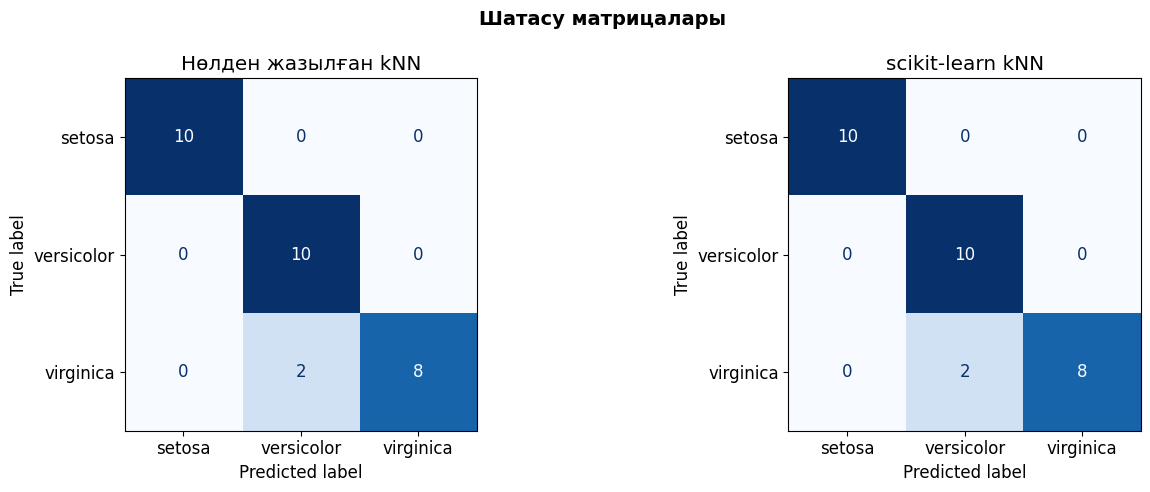

Шатасу матрицасын оқу:
Диагональ бойынша — дұрыс болжамдар
Диагональдан тыс — қателіктер


In [12]:
# Шатасу матрицасы (Confusion Matrix)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_scratch, y_pred_sklearn],
    ['Нөлден жазылған kNN', 'scikit-learn kNN']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)

plt.suptitle('Шатасу матрицалары', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Шатасу матрицасын оқу:')
print('Диагональ бойынша — дұрыс болжамдар')
print('Диагональдан тыс — қателіктер')

## 9. k параметрін іздеу

**Мақсат:** Оңтайлы k мәнін крест-валидация арқылы табу.

Оңтайлы k = 5
Ең жоғары крест-валидация дәлдігі: 0.9667


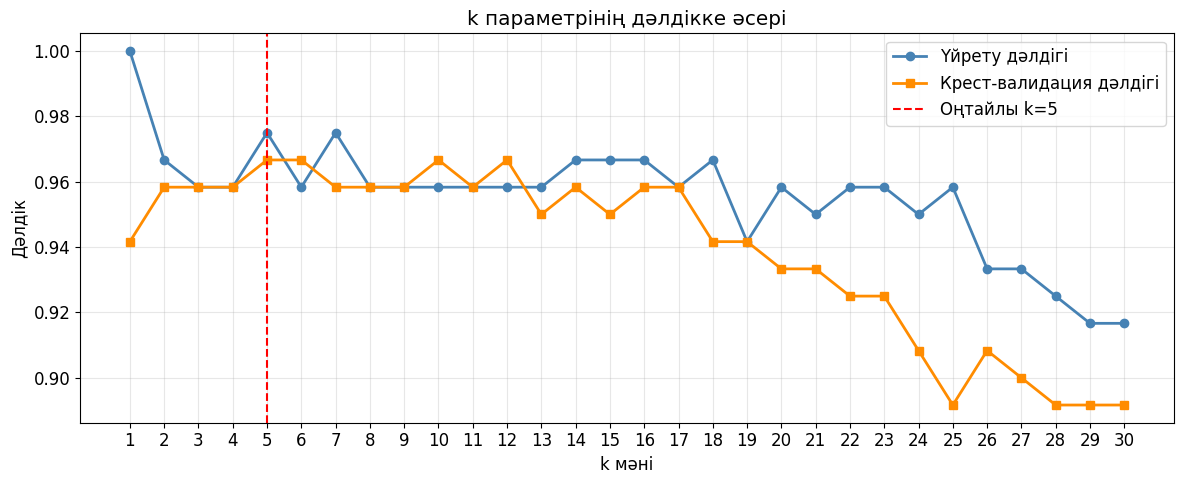

In [13]:
# Әртүрлі k мәндері үшін дәлдікті бағалау
k_values = range(1, 31)
train_scores = []
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    # Крест-валидация (5-fold)
    cv_score = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(cv_score.mean())

    # Үйрету дәлдігі
    knn.fit(X_train_scaled, y_train)
    train_scores.append(knn.score(X_train_scaled, y_train))

# Оңтайлы k
best_k = k_values[np.argmax(cv_scores)]
best_cv_score = max(cv_scores)
print(f'Оңтайлы k = {best_k}')
print(f'Ең жоғары крест-валидация дәлдігі: {best_cv_score:.4f}')

# Графикті салу
plt.figure(figsize=(12, 5))
plt.plot(k_values, train_scores, 'o-', color='steelblue', label='Үйрету дәлдігі', linewidth=2)
plt.plot(k_values, cv_scores, 's-', color='darkorange', label='Крест-валидация дәлдігі', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Оңтайлы k={best_k}')
plt.xlabel('k мәні')
plt.ylabel('Дәлдік')
plt.title('k параметрінің дәлдікке әсері')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

In [14]:
# Оңтайлы k мәнімен соңғы үлгіні үйрету
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

y_pred_final = knn_final.predict(X_test_scaled)
final_accuracy = accuracy_score(y_test, y_pred_final)

print(f'Соңғы үлгінің дәлдігі (k={best_k}): {final_accuracy:.4f} ({final_accuracy*100:.2f}%)')
print()
print('Соңғы классификация есебі:')
print(classification_report(y_test, y_pred_final, target_names=iris.target_names))

Соңғы үлгінің дәлдігі (k=5): 0.9333 (93.33%)

Соңғы классификация есебі:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



## 10. Шешім шекарасын визуализациялау

**Мақсат:** Алгоритмнің пространстрода шекараларды қалай анықтайтынын көрнекі түрде түсіну.

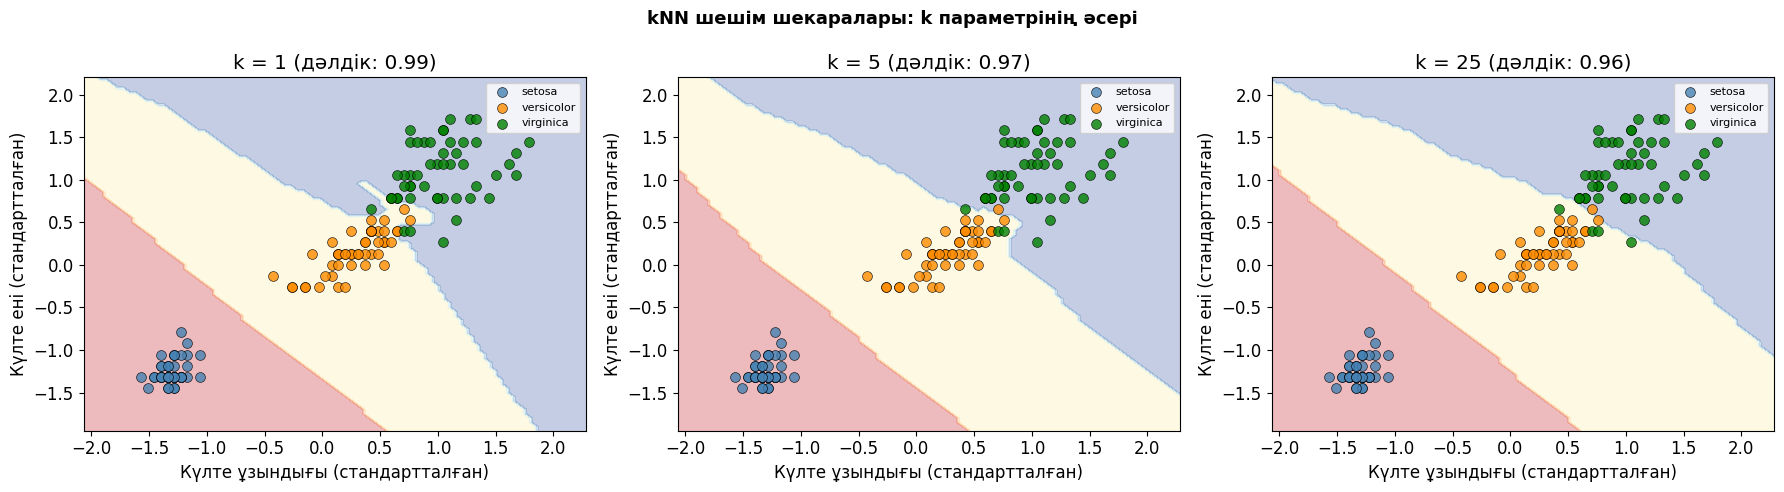

Солдан оңға: k=1 (асыра оқыту), оңтайлы k, k=25 (жетіспей оқыту)


In [15]:
# Тек 2 белгіні пайдаланып шешім шекарасын визуализациялау
X_2d = X[:, 2:4]  # petal length және petal width

scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, k in zip(axes, [1, best_k, 25]):
    knn_plot = KNeighborsClassifier(n_neighbors=k)
    knn_plot.fit(X_2d_scaled, y)

    # Тор нүктелерін жасау
    h = 0.05
    x_min, x_max = X_2d_scaled[:, 0].min() - 0.5, X_2d_scaled[:, 0].max() + 0.5
    y_min, y_max = X_2d_scaled[:, 1].min() - 0.5, X_2d_scaled[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = knn_plot.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)

    colors = ['steelblue', 'darkorange', 'green']
    for i, (species, color) in enumerate(zip(iris.target_names, colors)):
        mask = y == i
        ax.scatter(X_2d_scaled[mask, 0], X_2d_scaled[mask, 1],
                   c=color, label=species, alpha=0.8, s=50, edgecolors='k', linewidth=0.5)

    acc = knn_plot.score(X_2d_scaled, y)
    ax.set_title(f'k = {k} (дәлдік: {acc:.2f})')
    ax.set_xlabel('Күлте ұзындығы (стандартталған)')
    ax.set_ylabel('Күлте ені (стандартталған)')
    ax.legend(fontsize=8)

plt.suptitle('kNN шешім шекаралары: k параметрінің әсері', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Солдан оңға: k=1 (асыра оқыту), оңтайлы k, k=25 (жетіспей оқыту)')

## 11. Қорытынды

**Мақсат:** Сабақта меңгерілген негізгі ұғымдарды бекіту.

### Осы сабақта не үйрендік

kNN алгоритмінің негізгі сипаттамалары:

- **Параметрсіз алгоритм:** Деректердің үлестірімі туралы ешқандай болжам жасамайды
- **Жалқау оқу:** Үйрету кезеңінде ешнәрсе есептелмейді, есептеу болжам кезінде жүргізіледі
- **Артықшылықтары:** Қарапайым, интерпретациялауға болады, жаңа класстарды оңай қосуға болады
- **Кемшіліктері:** Үлкен деректерде болжам жасау баяу, жоғары өлшемділікте (curse of dimensionality) нашарлайды

### Негізгі гиперпараметрлер

- **k:** Көршілер саны — крест-валидация арқылы таңдалады
- **metric:** Арақашықтық өлшемі — есептің сипатына байланысты таңдалады
- **weights:** Салмақтау схемасы — uniform (тең) немесе distance (арақашықтыққа кері пропорционал)

### Есте сақтау керек

1. kNN алгоритмі үшін деректерді масштабтау міндетті
2. Масштабтауда тек үйрету жиынтығында `fit_transform`, тестілеу жиынтығында тек `transform` қолданылады
3. k мәнін таңдауда крест-валидация ең сенімді әдіс

## 12. Практикалық тапсырмалар

**Мақсат:** Меңгерілген білімді өз бетінше қолдану.

### Тапсырмалар

**1-тапсырма.** Нөлден жазылған KNNClassifierScratch класына регрессия функциясын қосыңыз. Болжам үшін k көршінің мәндерінің орташасын қолданыңыз.

**2-тапсырма.** Манхэттен метрикасымен k=7 пайдаланып Iris деректерінде модельді үйретіңіз. Евклид метрикасымен салыстырыңыз.

**3-тапсырма.** `sklearn.datasets.load_wine()` деректер жиынтығын жүктеп, kNN алгоритмін қолданыңыз. Оңтайлы k мәнін табыңыз.

**4-тапсырма (қосымша).** Масштабтаусыз және масштабтаумен жүргізілген тәжірибені салыстырып, нәтижелерін кесте түрінде көрсетіңіз.

2-тапсырма. Манхэттен метрикасымен k=7 пайдаланып Iris деректерінде модельді үйретіңіз. Евклид метрикасымен салыстырыңыз.

In [22]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np

In [17]:
iris = load_iris()
X, y = iris.data, iris.target

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
knn_manhattan = KNeighborsClassifier(n_neighbors=7, metric='manhattan')
knn_manhattan.fit(X_train, y_train)
y_pred_man = knn_manhattan.predict(X_test)

In [20]:
knn_euclidean = KNeighborsClassifier(n_neighbors=7, metric='euclidean')
knn_euclidean.fit(X_train, y_train)
y_pred_euc = knn_euclidean.predict(X_test)

In [21]:
print(f"Манхэттен метрикасы (k=7) дәлдігі: {accuracy_score(y_test, y_pred_man):.4f}")
print(f"Евклид метрикасы (k=7) дәлдігі: {accuracy_score(y_test, y_pred_euc):.4f}")

Манхэттен метрикасы (k=7) дәлдігі: 1.0000
Евклид метрикасы (k=7) дәлдігі: 0.9667


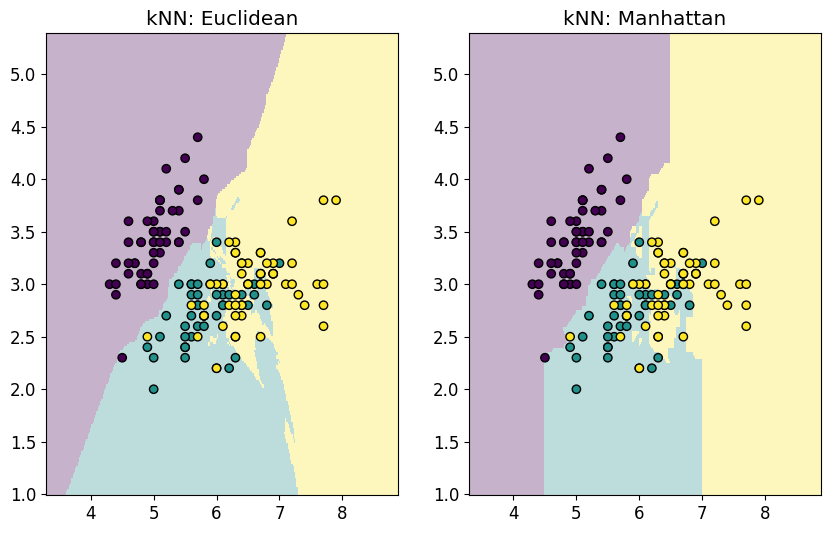

In [24]:

X = iris.data[:, :2]
y = iris.target

h = .02
metrics = ['euclidean', 'manhattan']

for i, metric in enumerate(metrics):
    clf = KNeighborsClassifier(n_neighbors=7, metric=metric)
    clf.fit(X, y)


    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.subplot(1, 2, i + 1)
    plt.pcolormesh(xx, yy, Z, alpha=0.3, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='viridis')
    plt.title(f"kNN: {metric.capitalize()}")

plt.show()